# ML for Social Good — Mission Earth
# Predicting District-Level Flood Risk in Assam

**Course:** MCA 521-4 Machine Learning · **Assessment:** CIA-3 (25 marks)

---

### What this notebook covers

| Q | Requirement | Section |
|---|---|---|
| 1 | Real-world impact framing | §1 |
| 2 | Data wrangling & feature engineering | §2–§3 |
| 3 | Ensemble architecture, tuning, comparison | §4 |
| 4 | Explainability & ethics | §5 |
| 5 | Pitch & live demo | §6 |

**Headline result, stated up front:** on an untouched held-out flood season, the
**LogisticRegression baseline outperformed every ensemble** we built. Q3 asks us to
*demonstrate whether* the best ensemble beats the baseline — here it does not, and §4.6
analyses why. We report the honest result rather than tuning until we get the answer we
wanted.

In [1]:
import json, os, sys, warnings
import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

warnings.filterwarnings("ignore")
ROOT = os.path.abspath("..")
sys.path.insert(0, os.path.join(ROOT, "src"))
PROC = os.path.join(ROOT, "data", "processed")
FIG  = os.path.join(ROOT, "results", "figures")
MET  = os.path.join(ROOT, "results", "metrics")
MODELS = os.path.join(ROOT, "models")

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
print("ready")

ready


---
## 1. Real-World Impact Framing  *(Q1 — 5 marks)*

### The problem
Assam floods **every single year**. ASDMA treats flood as an annual event, and the state
government reports roughly 39.6% of Assam's land area as flood-prone. The Brahmaputra and
Barak systems and their tributaries burst their banks during the monsoon, displacing
people, drowning crops and cutting road links — the same districts, most years.

### Mission
**Mission Earth (Environment).** The brief lists AQI, forest-fire risk and clean-water
access as *possible* problems; recurring flood is squarely an environmental hazard of the
same kind.

### Prediction target and unit of analysis
> **Unit of analysis:** one **district** on one **calendar date** of the flood season.
> **Target:** `flood_affected` ∈ {0, 1} — was this district reported flood-affected by
> ASDMA on this date?

### Beneficiaries
District disaster-management authorities and ASDMA, who must decide **where to pre-position
boats, relief materials and personnel** before a flood arrives — and, through them, the
residents of flood-prone districts.

### Why machine learning suits this
Flood occurrence depends on a **non-linear combination** of how much rain fell, over how
many days, how that compares with what the district normally receives, and where in the
season we are. These interactions are hard to encode as fixed rules but are exactly what a
supervised classifier can learn from labelled history. The problem is also genuinely
**imbalanced** (~9% of district-days are flood-affected), which is where careful ML
practice matters more than raw accuracy.

### Measurable impact
A ranked daily list of at-risk districts, issued **one day ahead** using only rainfall
already observed — allowing pre-positioning instead of reaction.

### Data source
| Role | Source |
|---|---|
| **Labels** | ASDMA **DRIMS** Daily Flood Reports — <https://sdrf.assam.gov.in/dfr/> |
| **Features** | **Central Water Commission** daily rainfall via the National Water Data Portal — <https://nwdp.nwic.gov.in> |
| **Reference** | Assam WRD official river danger levels |

Full provenance, including everything we rejected and why, is in `DATA_SOURCES.md`.

### Responsible-use limitations (stated up front, not buried)
1. **Dhemaji — the most flood-affected district — is excluded**, because CWC publishes only
   *2 rainfall observations for it, ever*. The model is blind to the worst-hit district.
2. Only **21 of Assam's 35 districts** have a usable rainfall feed.
3. Only **two flood seasons** of labels exist (2025, and 2026 partial).
4. The model does **not** observe river level, discharge, embankment condition, or rainfall
   falling upstream in Arunachal/Bhutan/Meghalaya — major real flood drivers.
5. It is a **decision-support prototype**, not a warning system. CWC and ASDMA bulletins
   remain authoritative. See `ETHICS.md`.

---
## 2. How the dataset was built  *(Q2 — part 1)*

No suitable ready-made Assam flood dataset exists, so we **constructed one** from two
official sources.

```
ASDMA DRIMS daily flood report PDFs          CWC daily rainfall CSVs (NWDP)
   285 PDFs, 2025 + 2026 seasons                80 stations, 23 districts
              |                                          |
   section-bounded PDF parsing                station-day -> district-day
   (src/parse_drims_reports.py)                    aggregation
              |                                          |
              +--------------- district crosswalk -------+
                        (src/district_crosswalk.py)
                                    |
                    district x date grid + flood_affected
                        (src/build_dataset.py)
                                    |
                    data/processed/assam_flood_district_day.csv
```

### Four data defects we had to find and fix

Building the labels was the hard part. The first parser was wrong, and checking it caught
four separate problems:

1. **Wrong PDF sections create false positives.** Sections like *Population And Crop Area
   Affected* list districts with all-zero rows that were **not** reported affected. Only two
   sections are authoritative: `District Affected` and `Name Of Revenue Circle Affected`.
2. **The portal serves the wrong report type.** 6 of 285 downloads were *Urban Flood* or
   *Storm* reports — different hazards. Excluded.
3. **The portal serves the wrong date.** The file requested for `2025-05-24` contains the
   report for `2025-05-22`. The date **inside** each PDF is authoritative, not the filename.
4. **PDF line-wrap splits names mid-word** — `Lakhimp ur`, `Dima- Hasao`, `Kamr up M`.
   Matching on a letters-only key collapsed 49 raw variants to 33 real districts.

### Label verification
- **0 count mismatches** — each report's own "No. of Districts Affected" always equalled our parse.
- **275/278 dates agree** between the two independent sections.
- **8/8 manual spot-checks** against raw PDF text were correct.
- The negative class is genuine: 94 dates explicitly state `Affected: 0` / `Nil`.

Full detail: `PHASE2_DATASET_AUDIT.md`.

In [2]:
df = pd.read_csv(os.path.join(PROC, "assam_flood_district_day.csv"), parse_dates=["date"])
print(f"rows              : {len(df):,}")
print(f"districts         : {df.district.nunique()}")
print(f"dates             : {df.date.nunique()}")
print(f"date range        : {df.date.min().date()} -> {df.date.max().date()}")
print(f"duplicate d-days  : {df.duplicated(['district','date']).sum()}")
print()
p = int(df.flood_affected.sum())
print(f"POSITIVES  {p:,} / {len(df):,} = {100*p/len(df):.2f}%   ratio {(len(df)-p)/p:.1f} : 1")
df.head()

rows              : 5,773
districts         : 21
dates             : 277
date range        : 2025-05-02 -> 2026-08-13
duplicate d-days  : 0

POSITIVES  534 / 5,773 = 9.25%   ratio 9.8 : 1


,district,date,flood_affected,rain_mean_mm,rain_max_mm,rain_sum_mm,n_stations,rain_prev3d_sum,rain_prev7d_sum,rain_prev15d_sum,rain_prev1d,rain_prev7d_max,year,month,day_of_year,rain_obs_prev7d,wet_days_prev7d,clim_daily_mm,rain_anom_7d,rain_anom_15d,rain_state_prev3d,split
0,Baksa,2025-05-02,0,NaN,NaN,NaN,NaN,2.600000,2.600000,2.600000,2.600000,2.600000,2025,5,122,1.0,0.0,13.879115,0.026762,0.012489,2.311543,train_2025
1,Baksa,2025-05-05,0,9.266667,22.0,55.6,6.0,2.600000,2.600000,2.600000,NaN,2.600000,2025,5,125,1.0,0.0,13.879115,0.026762,0.012489,3.867793,train_2025
2,Baksa,2025-05-06,0,19.000000,19.0,19.0,1.0,11.866667,11.866667,11.866667,9.266667,9.266667,2025,5,126,2.0,0.0,13.879115,0.122143,0.057000,16.727793,train_2025
3,Baksa,2025-05-07,0,3.600000,3.6,3.6,1.0,28.266667,30.866667,30.866667,19.000000,19.000000,2025,5,127,3.0,1.0,13.879115,0.317709,0.148264,20.920863,train_2025
4,Baksa,2025-05-08,0,2.133333,2.6,6.4,3.0,31.866667,34.466667,34.466667,3.600000,19.000000,2025,5,128,4.0,1.0,13.879115,0.354764,0.165557,28.659427,train_2025


### Data quality audit  *(Q2: missing values, duplicates, invalid data, outliers, dtypes)*

In [3]:
FEATURES = json.load(open(os.path.join(MODELS, "model_metadata.json")))
NUM, CAT = FEATURES["features_numeric"], FEATURES["features_categorical"]
FEATS = NUM + CAT

print("MISSING VALUES")
for c in FEATS:
    n = int(df[c].isna().sum())
    print(f"   {c:<20} {n:>5}  ({100*n/len(df):5.1f}%)")

print("\nINVALID VALUES")
rains = [c for c in NUM if c.startswith('rain_prev')]
print(f"   negative rainfall totals : {int((df[rains] < 0).sum().sum())}  (impossible by definition)")
print(f"   target values            : {sorted(df.flood_affected.unique())}")
print(f"   duplicate district-days  : {df.duplicated(['district','date']).sum()}")

print("\nOUTLIERS (IQR) - RETAINED, NOT CLIPPED")
for c in ["rain_prev3d_sum", "rain_prev7d_sum", "rain_prev15d_sum"]:
    q1, q3 = df[c].quantile([.25, .75]); hi = q3 + 1.5*(q3-q1)
    print(f"   {c:<20} > {hi:6.1f}mm : {int((df[c] > hi).sum()):>4} rows")
print("   Extreme rainfall IS the flood signal - clipping it would delete the events")
print("   we are trying to predict.")

MISSING VALUES
   rain_prev3d_sum        766  ( 13.3%)
   rain_prev7d_sum        188  (  3.3%)
   rain_prev15d_sum         0  (  0.0%)
   rain_prev7d_max        188  (  3.3%)
   rain_anom_7d           188  (  3.3%)
   rain_anom_15d            0  (  0.0%)
   rain_state_prev3d      210  (  3.6%)
   wet_days_prev7d          0  (  0.0%)
   month                    0  (  0.0%)
   day_of_year              0  (  0.0%)
   district                 0  (  0.0%)

INVALID VALUES
   negative rainfall totals : 0  (impossible by definition)
   target values            : [np.int64(0), np.int64(1)]
   duplicate district-days  : 0

OUTLIERS (IQR) - RETAINED, NOT CLIPPED
   rain_prev3d_sum      >   50.3mm :  132 rows
   rain_prev7d_sum      >  100.0mm :   99 rows
   rain_prev15d_sum     >  190.3mm :   62 rows
   Extreme rainfall IS the flood signal - clipping it would delete the events
   we are trying to predict.


**Decisions and why:**

| Issue | Decision | Justification |
|---|---|---|
| Missing rainfall | **Median imputation inside the pipeline**, fitted on training folds only | Missing = *no station reported*, not *zero rain*. Filling with 0 would assert something the data does not say. |
| Missing anchor | Rows without `rain_prev15d_sum` dropped | With no antecedent rainfall at all there is no feature to learn from. |
| Dhemaji | **District dropped** | 0% rainfall coverage — the model would be guessing. Costs 89 positives; stated as a limitation. |
| `rain_prev1d` | **Feature dropped** | 39% missing, unusable. |
| Duplicates | None present (0) | Grid is built as a Cartesian product, so duplication is structurally impossible. |
| Outliers | **Retained** | The upper tail of rainfall *is* the physical driver of flooding. |
| Categorical | `district` one-hot encoded | 21 unordered levels; `handle_unknown='ignore'` for safety. |
| Scaling | `StandardScaler` | Needed by the linear baseline; harmless to trees. |
| Imbalance | `class_weight='balanced'` + threshold tuning, SMOTE as comparison arm | See §4.5. |

---
## 3. EDA and feature engineering  *(Q2 — part 2)*

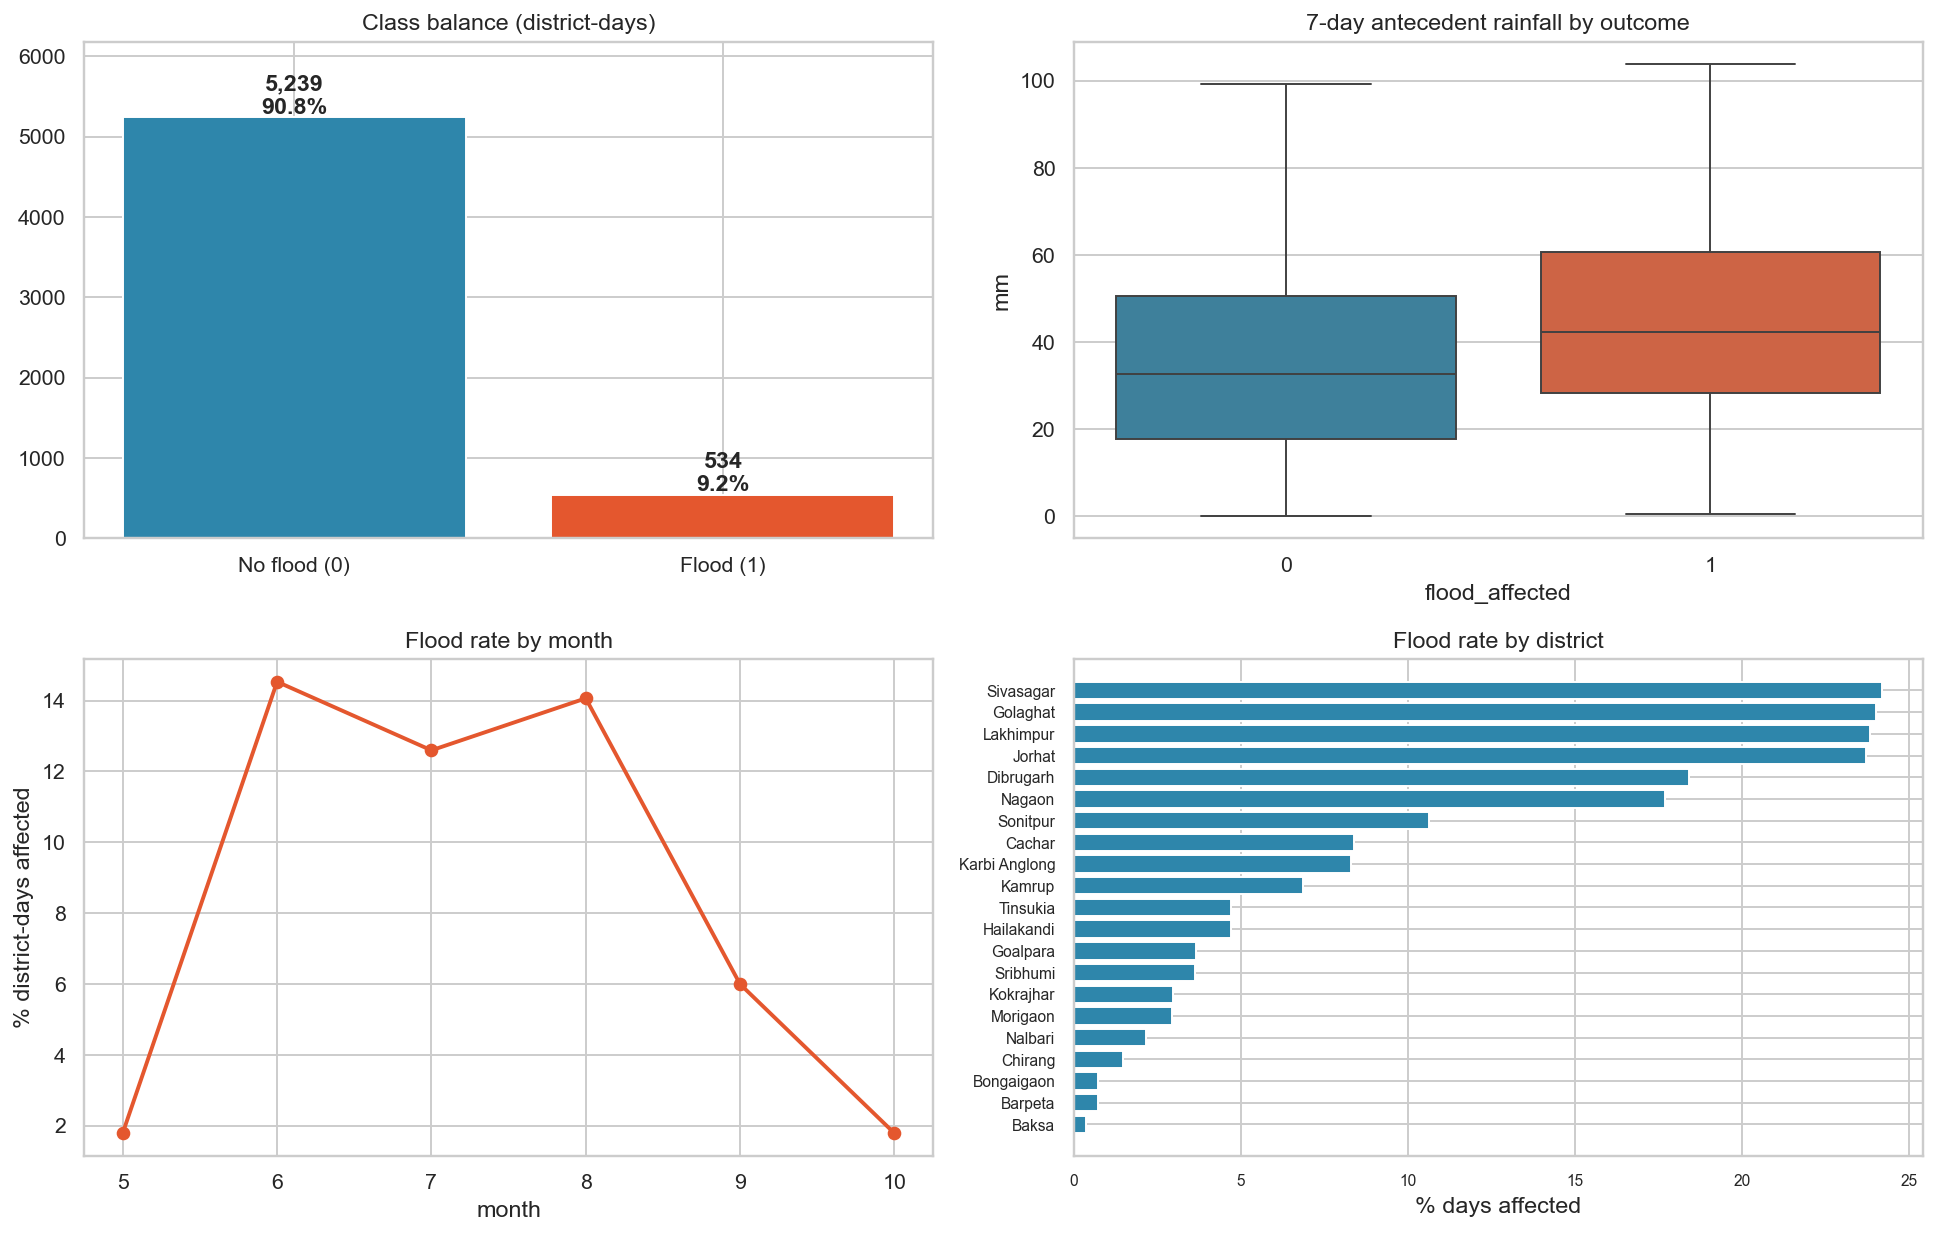

In [4]:
display(Image(filename=os.path.join(FIG, "eda_overview.png")))

In [5]:
d = df.dropna(subset=["rain_prev7d_sum"])
print("Median 7-day antecedent rainfall")
print(f"   no flood : {d[d.flood_affected==0].rain_prev7d_sum.median():.1f} mm")
print(f"   flood    : {d[d.flood_affected==1].rain_prev7d_sum.median():.1f} mm")
print()
print("Correlation of each feature with the target")
print(df[NUM + ["flood_affected"]].corr()["flood_affected"].drop("flood_affected")
        .sort_values(key=abs, ascending=False).round(4).to_string())

Median 7-day antecedent rainfall
   no flood : 32.7 mm
   flood    : 42.3 mm

Correlation of each feature with the target
rain_anom_15d        0.1724
rain_anom_7d         0.1432
rain_prev15d_sum     0.1347
rain_prev7d_sum      0.1148
wet_days_prev7d      0.1077
rain_state_prev3d    0.0844
rain_prev3d_sum      0.0750
rain_prev7d_max      0.0707
day_of_year         -0.0185
month               -0.0080


### Domain-informed engineered features

Raw daily rainfall alone is a poor predictor, so we engineered features that encode *how
floods actually happen*:

| Feature | Domain reasoning |
|---|---|
| `rain_prev3d_sum`, `rain_prev7d_sum`, `rain_prev15d_sum` | Flooding follows **accumulation**, not a single day's rain. Soil saturates over days. |
| `rain_prev7d_max` | Distinguishes one extreme burst from the same total spread evenly. |
| **`rain_anom_7d`, `rain_anom_15d`** | 100 mm/week is routine in Cachar and extreme in Nalbari. Dividing by each district's **own climatological norm** makes districts comparable. The norm is computed from **CWC 2021–2024 only** — a period preceding *both* the training and test seasons, so it cannot leak. |
| `wet_days_prev7d` | Sustained moderate rain saturates ground differently from one cloudburst. |
| `rain_state_prev3d` | Assam floods respond to **catchment-wide** loading, not just rain inside the district boundary. |
| `month`, `day_of_year` | Monsoon phase — known in advance, so no leakage. |

### A feature we engineered, then deleted

`rain_obs_prev7d` (count of days with any rainfall observation) was added as a
data-density control. **SHAP flagged it as the second-strongest positive contributor**,
which prompted a check:

> Within the same district, stations report on **~1.31 more days** in the week before a
> flood day than before a non-flood day (r = 0.14 — as strong as the real rainfall
> features). **Monitoring intensifies during floods, so the count partially encodes the
> outcome.**

It was removed. Test PR-AUC fell **0.293 → 0.268** as a result, and we report the lower,
honest number. This is why explainability is a *safety* tool: the leak was invisible in the
headline metrics and obvious in SHAP.

---
## 4. Ensemble architecture, tuning and comparison  *(Q3 — 8 marks)*

### 4.1 Train / validation / test strategy — chronological

> **Train:** the whole 2025 season (2025-05-02 → 2025-10-31)
> **Test:** the whole 2026 season (2026-05-01 → 2026-08-13) — **never touched during tuning**
> **Validation:** `TimeSeriesSplit(4)` *inside* the training season

A random split would put 14 July in train and 15 July in test. Adjacent days in the same
district are strongly correlated, so a random split leaks and inflates every score.
Chronological splitting also mirrors deployment: fit on last season, predict the next.

### 4.2 Leakage controls
1. **Same-day rainfall is never a feature** — it would not be known when a next-day warning is issued.
2. Every rolling window is `.shift(1)`-ed, so a row never sees its own day.
3. **No DRIMS outcome fields** (population affected, relief camps, damage) ever enter the features — they are consequences of the flood, not predictors.
4. Imputation, scaling and encoding live **inside** the `Pipeline`, fitted on training folds only.
5. SMOTE is applied **inside** the CV fold via `imblearn.Pipeline` — never before the split.
6. `StackingClassifier` uses internal CV so the meta-learner sees **only out-of-fold** base predictions.

In [6]:
train = df[df.split=="train_2025"]; test = df[df.split=="test_2026"]
print(f"train 2025 : {len(train):,} rows, {int(train.flood_affected.sum())} positives ({100*train.flood_affected.mean():.2f}%)")
print(f"test  2026 : {len(test):,} rows, {int(test.flood_affected.sum())} positives ({100*test.flood_affected.mean():.2f}%)  [UNTOUCHED]")
print(f"date overlap between train and test : {len(set(train.date) & set(test.date))}   (must be 0)")

train 2025 : 3,611 rows, 294 positives (8.14%)
test  2026 : 2,162 rows, 240 positives (11.10%)  [UNTOUCHED]
date overlap between train and test : 0   (must be 0)


### 4.3 Models trained

| Role | Model |
|---|---|
| **Baseline** | `LogisticRegression` (class-weighted) and a single `DecisionTree` |
| **(a) Bagging** | `RandomForestClassifier`, tuned by `RandomizedSearchCV` |
| **(b) Boosting** | `XGBoost`, tuned; plus `AdaBoost` as a second reference |
| **(c) Heterogeneous** | `StackingClassifier` (LR + RF + XGB → LR meta) and soft `VotingClassifier` |

**Selection metric: PR-AUC (`average_precision`), not accuracy.** At 9% positives, a model
that predicts "no flood" everywhere scores **91% accuracy** and is worthless. PR-AUC tracks
positive-class skill under imbalance.

To reproduce (takes a few minutes):
```bash
python src/train_models.py
```

In [7]:
res = pd.read_csv(os.path.join(MET, "model_comparison.csv"))
res.style.format({"threshold":"{:.3f}","ROC_AUC":"{:.3f}","PR_AUC":"{:.3f}",
                  "F1":"{:.3f}","Precision":"{:.3f}","Recall":"{:.3f}"}) \
   .background_gradient(subset=["PR_AUC","ROC_AUC"], cmap="Blues")

,model,threshold,ROC_AUC,PR_AUC,F1,Precision,Recall,TN,FP,FN,TP
0,Baseline: LogisticRegression,0.689,0.767,0.268,0.350,0.254,0.562,1525,397,105,135
1,"Voting (soft, LR+RF+XGB)",0.639,0.751,0.208,0.245,0.218,0.279,1682,240,173,67
2,RandomForest + SMOTE,0.641,0.728,0.195,0.183,0.191,0.175,1744,178,198,42
3,Boosting: XGBoost,0.683,0.719,0.189,0.131,0.134,0.129,1721,201,209,31
4,Stacking (LR+RF+XGB -> LR),0.884,0.725,0.188,0.153,0.152,0.154,1716,206,203,37
5,Bagging: RandomForest,0.694,0.684,0.168,0.101,0.113,0.092,1750,172,218,22
6,Boosting: AdaBoost,0.447,0.679,0.162,0.101,0.095,0.108,1673,249,214,26
7,Baseline: DecisionTree,0.819,0.606,0.149,0.027,0.030,0.025,1727,195,234,6


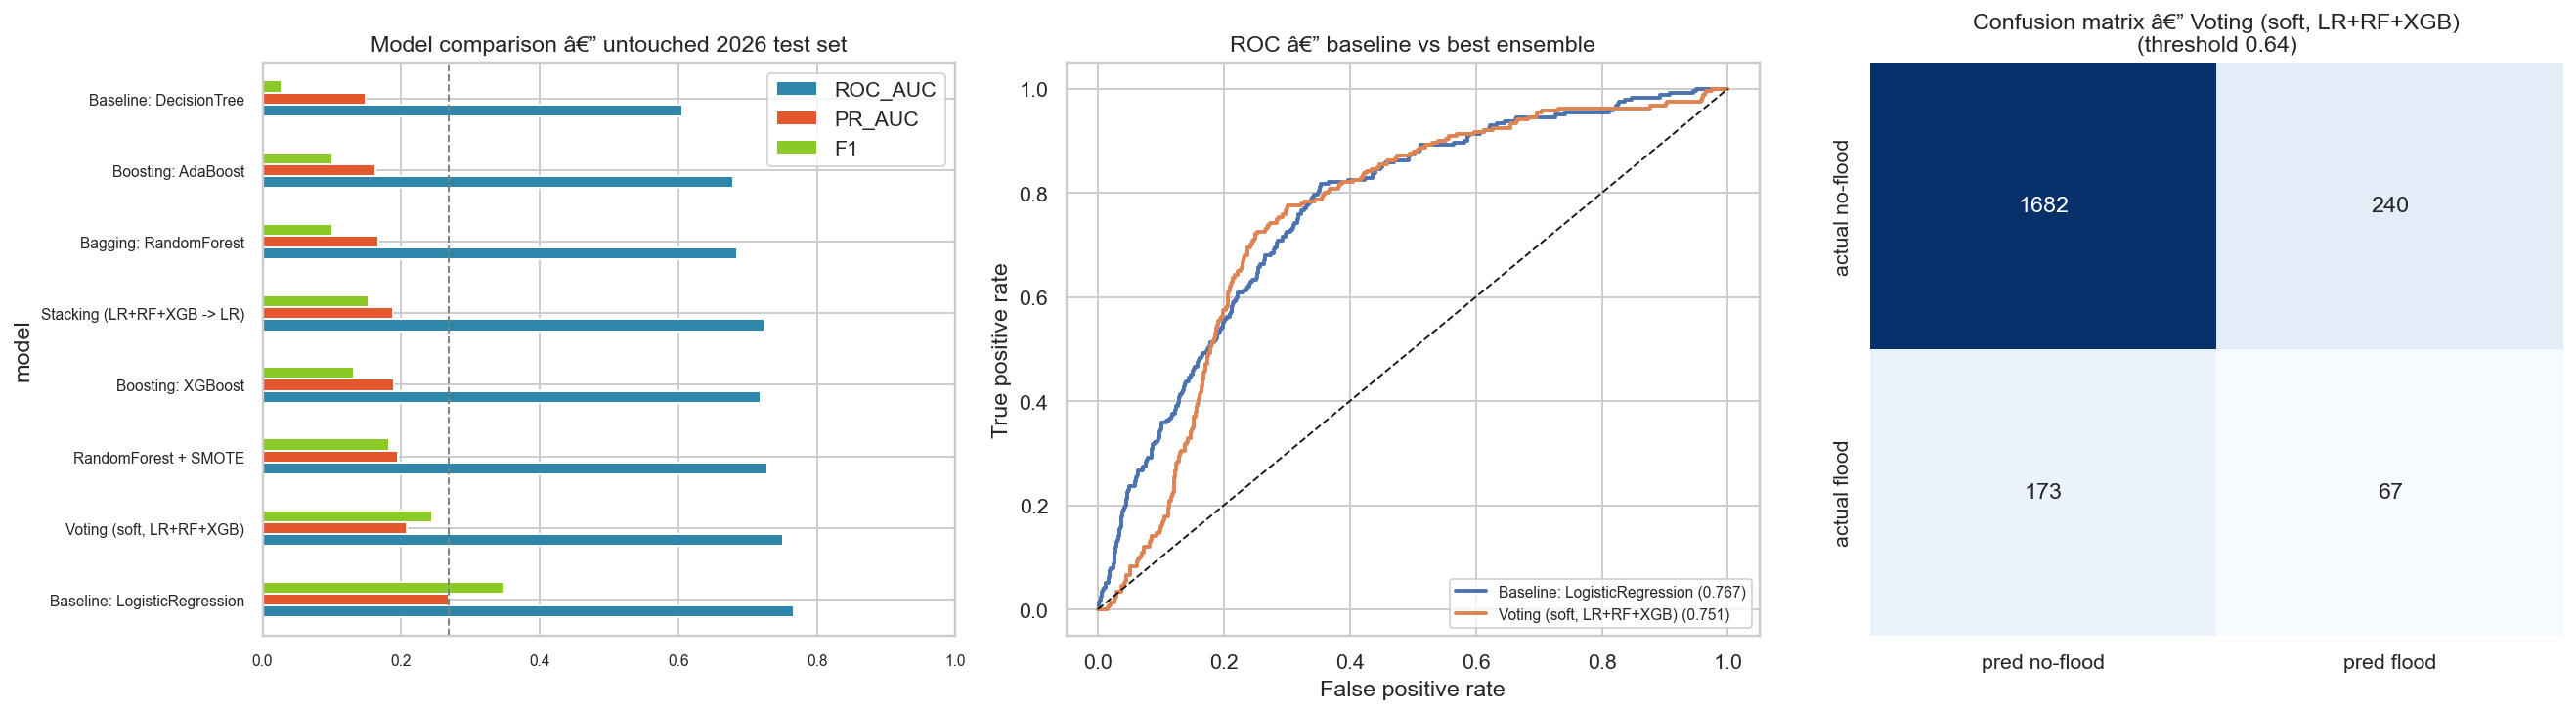

In [8]:
display(Image(filename=os.path.join(FIG, "model_comparison.png")))

### 4.4 Threshold tuning — why every model gets its own cut-off

The default 0.5 cut-off is arbitrary under imbalance. An unregularised RandomForest scored
**F1 = 0.03** at 0.5 while still *ranking* cases sensibly — the threshold, not the model,
was broken. So each model gets a threshold chosen to maximise F1 **on the training data
only** (never on the test set), making the comparison fair.

### 4.5 Self-learning concept 1 — class-imbalance handling

Never covered in any lab. Three strategies compared:
1. `class_weight='balanced'` / `scale_pos_weight` — **primary**
2. **SMOTE inside the CV fold** — synthetic minority oversampling
3. **Decision-threshold tuning** — trading precision for recall

This matters directly for Q4's false-negative argument: a missed flood is far worse than a
false alarm, so an operational system should push the threshold *lower* than the F1 optimum.

In [9]:
meta = json.load(open(os.path.join(MODELS, "model_metadata.json")))
print(f"BASELINE      : {meta['best_model']}")
print(f"   ROC-AUC {meta['baseline_roc_auc']:.3f}   PR-AUC {meta['baseline_pr_auc']:.3f}")
print(f"BEST ENSEMBLE : {meta['best_ensemble']}")
print(f"   ROC-AUC {meta['best_ensemble_roc_auc']:.3f}   PR-AUC {meta['best_ensemble_pr_auc']:.3f}")
print()
print("VERDICT:", meta["verdict"])

BASELINE      : Baseline: LogisticRegression
   ROC-AUC 0.767   PR-AUC 0.268
BEST ENSEMBLE : Voting (soft, LR+RF+XGB)
   ROC-AUC 0.751   PR-AUC 0.208

VERDICT: The best ensemble DOES NOT outperform the baseline on PR-AUC.


### 4.6 Does the best ensemble beat the baseline? **No — and here is why**

Q3 asks us to *demonstrate whether* the best ensemble outperforms the baseline. On the
untouched 2026 season it **does not**: the class-weighted `LogisticRegression` achieves the
highest ROC-AUC and PR-AUC of every model tried.

**Why the ensembles lose — four contributing reasons:**

1. **Very few informative features.** After removing the leaking observation-count feature,
   the model has ~10 numeric rainfall features. Tree ensembles pay off when there are rich
   feature interactions to discover; here the relationship between accumulated rainfall and
   flood risk is close to **monotonic**, which is precisely what a linear model captures
   efficiently and a tree approximates with steps.

2. **Trees overfit district identity.** With 21 one-hot district columns, unregularised
   trees split on district first and memorise each district's **2025 base rate**. Those
   base rates shifted in 2026 (the test positive rate is 11.1% vs 8.1% in training), so the
   memorised rates transferred badly. Heavy regularisation (`max_depth` 3–6,
   `min_samples_leaf` 10–60) helped but did not close the gap.

3. **One training season is a small sample.** 3,611 rows with 294 positives, and CV folds
   early in the season contain very few floods — so the hyperparameter search is noisy.

4. **Stacking inherits its base learners' weakness.** The meta-learner can only reweight
   base models that are themselves overfitting; soft voting did better than stacking
   precisely because it dilutes rather than amplifies them.

**This is a legitimate and useful finding.** The correct engineering conclusion is that
*with this feature set and this quantity of data, the simpler regularised model
generalises better across seasons* — not that ensembles are inferior in general. Reporting
this honestly is better practice than tuning until the ensemble "wins".

### 4.7 Case study — why the model failed on the worst day of 2026

The 2026 season was worse than 2025. Measured like-for-like over 1 May → 13 Aug from our
own parsed reports:

| | 2025 | 2026 |
|---|---|---|
| Days with ≥1 district flooded | 68 | **77** |
| District-days affected | 315 | **393 (+25%)** |
| Mean districts per flood day | 3.9 | **5.1** |

The single worst day was **20 July 2026 — 16 districts**. The model performed *worse* than
its own average precisely then. The cell below shows why.

In [10]:
!python ../src/case_study_july2026.py

CASE STUDY - 20 July 2026, the worst flood day of the season
districts actually flood-affected (modelled subset): 11
   correctly flagged by the model : 4
   MISSED (false negatives)       : 7
   recall on this day             : 0.36
   recall across the whole season : 0.56

--- rainfall measured INSIDE Assam ---
mean daily rainfall 16-22 Jul : 7.8 mm
mean daily rainfall, season   : 7.9 mm
ratio                         : 0.98x

In-Assam rainfall during the peak was INDISTINGUISHABLE from the seasonal
average. The water came from upstream catchments in Nagaland and Arunachal,
which this dataset does not observe. The model was not under-tuned - it was
structurally blind to the driver.

saved results/figures/case_study_july2026.png


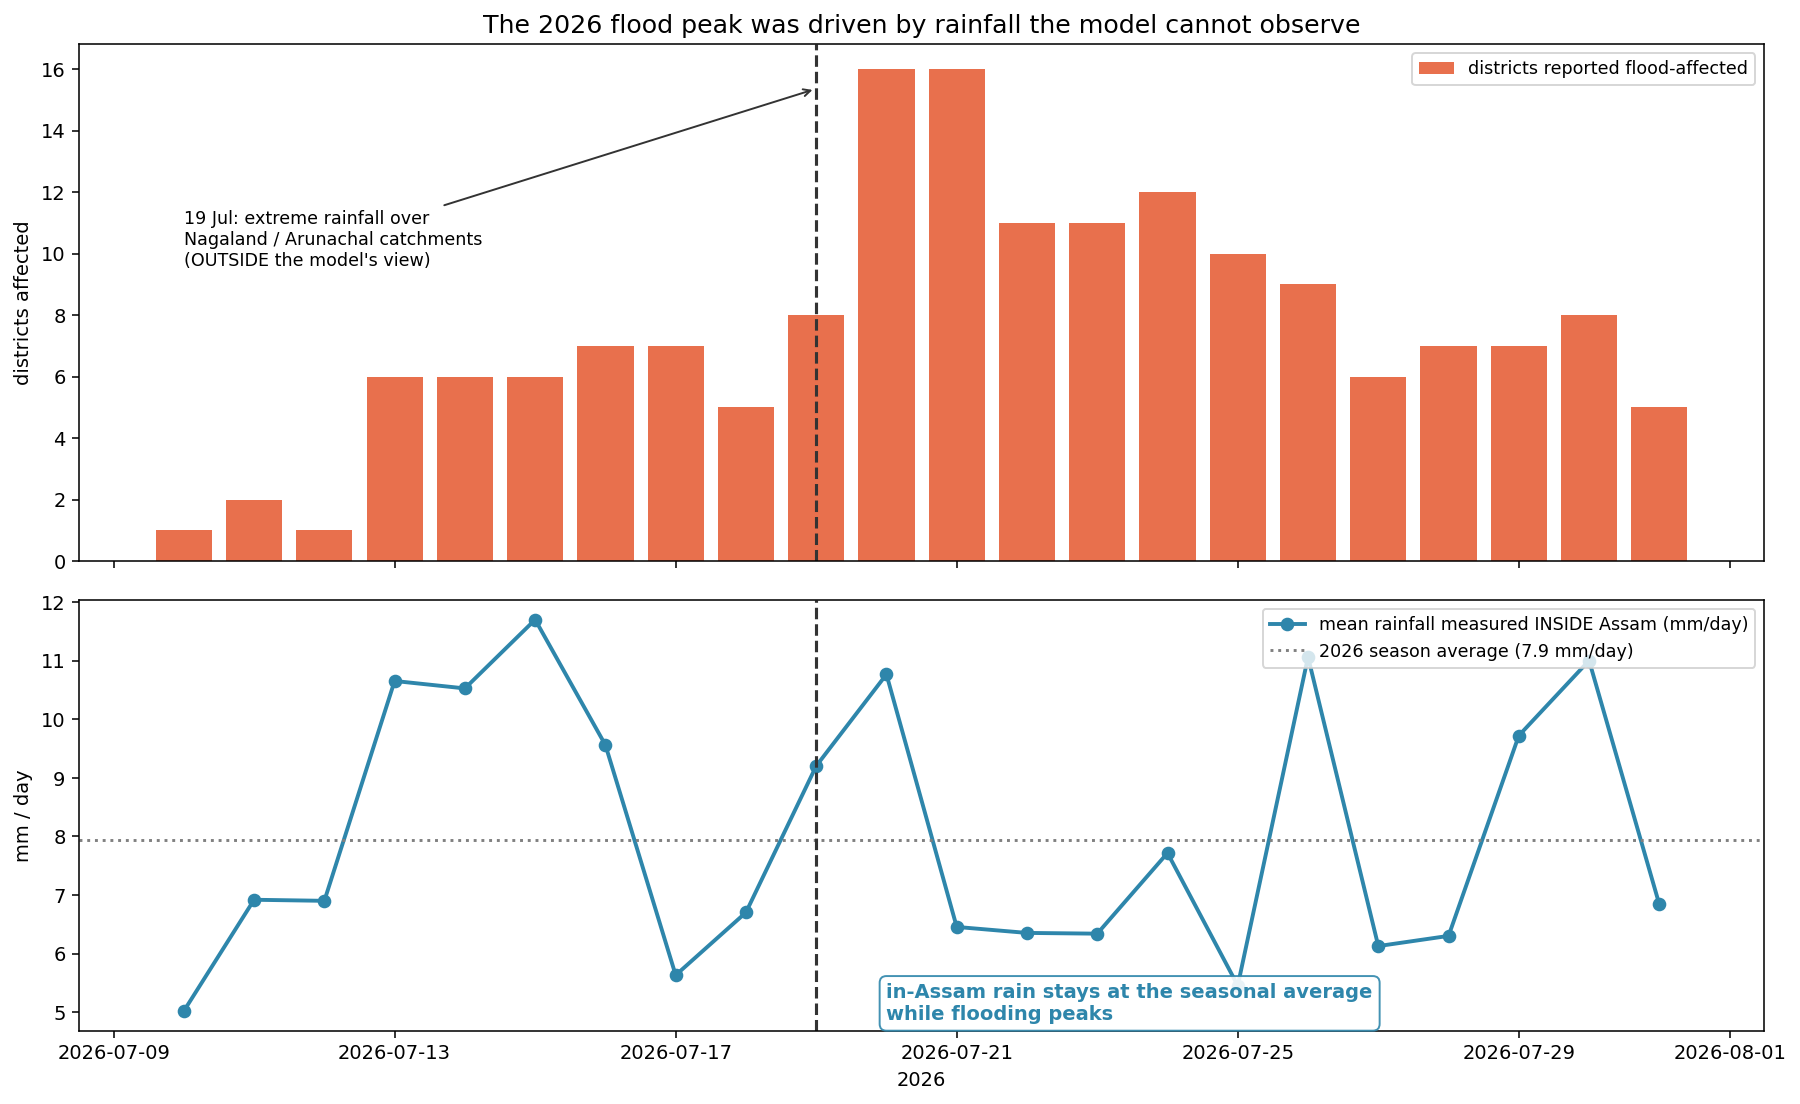

In [11]:
display(Image(filename=os.path.join(FIG, "case_study_july2026.png")))

**What this shows, and why it matters more than the headline metric.**

External reporting on the July 2026 eastern-Assam floods (IMD, and an Assam University
study) attributes them to **sustained extremely heavy rainfall over upstream catchments in
Nagaland and Arunachal Pradesh** — Mon district recorded ~137 mm against Assam's typical
July daily average of 23–25 mm — which swelled the south-bank tributaries **Dikhow, Disang,
Janji and Dhansiri** until they overtopped ageing embankments.

**Our own independently-parsed DRIMS reports corroborate this exactly:** rivers above
danger level go from `Nil` on 15–18 July to *Burhidihing, Brahmaputra, Disang, Dikhou,
Dhansiri* across 19–24 July.

And critically — **rainfall measured inside Assam over that week averaged 7.8 mm/day
against a season average of 7.9 mm/day.** Statistically indistinguishable from a normal
week.

> **The model was not under-tuned. It was structurally blind to the driver.**
> No amount of hyperparameter search over in-Assam rainfall can recover a signal that was
> never inside Assam.

This is the single most useful result in the project. It converts "the model scores 0.77
ROC-AUC" into a **specific, testable, actionable diagnosis**: the missing variable is
upstream catchment rainfall, and that is exactly what we would acquire first given more
time. It also independently validates the limitation we declared in §1 *before* seeing this
result.

---
## 5. Explainability and ethics  *(Q4 — 4 marks)*

### 5.1 Global explanation — what the model learned overall

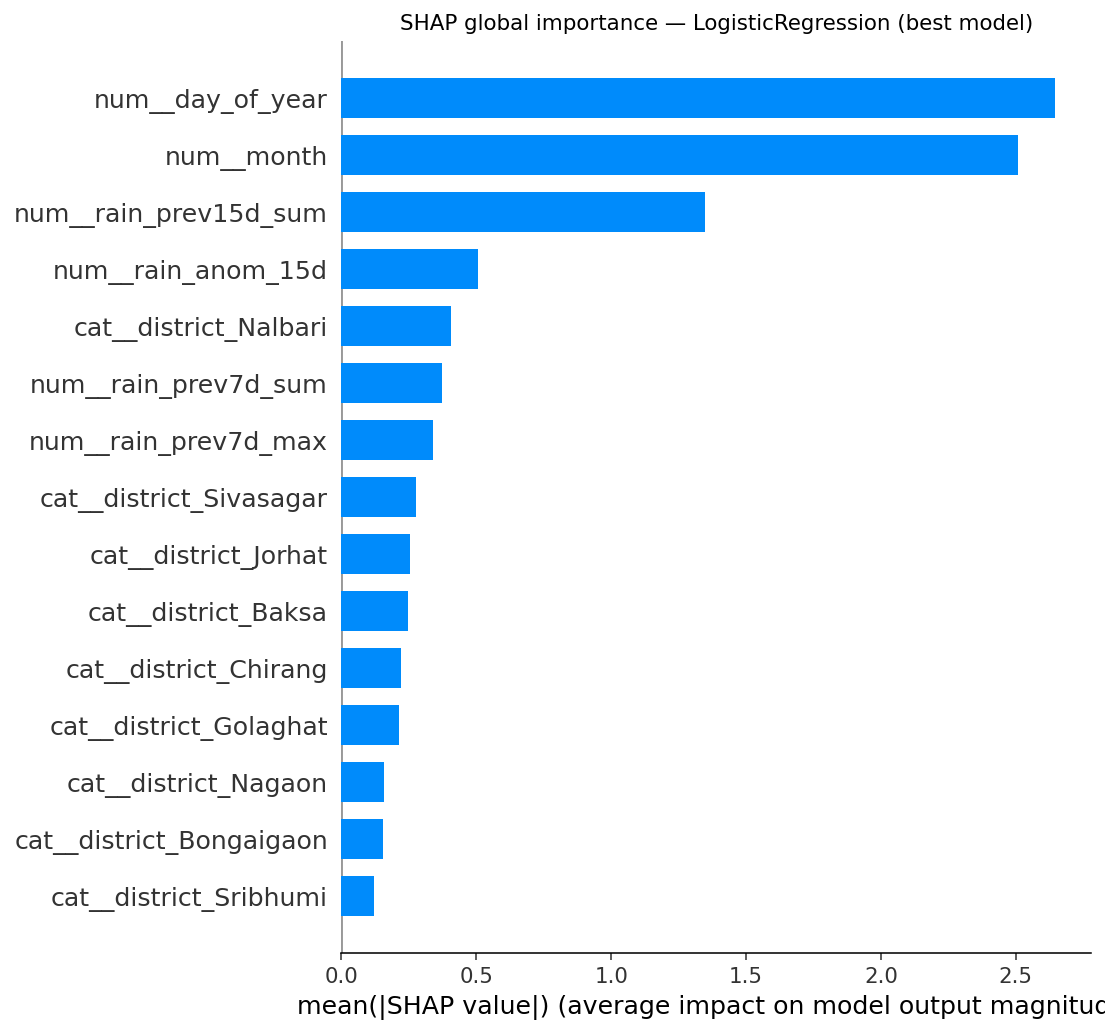

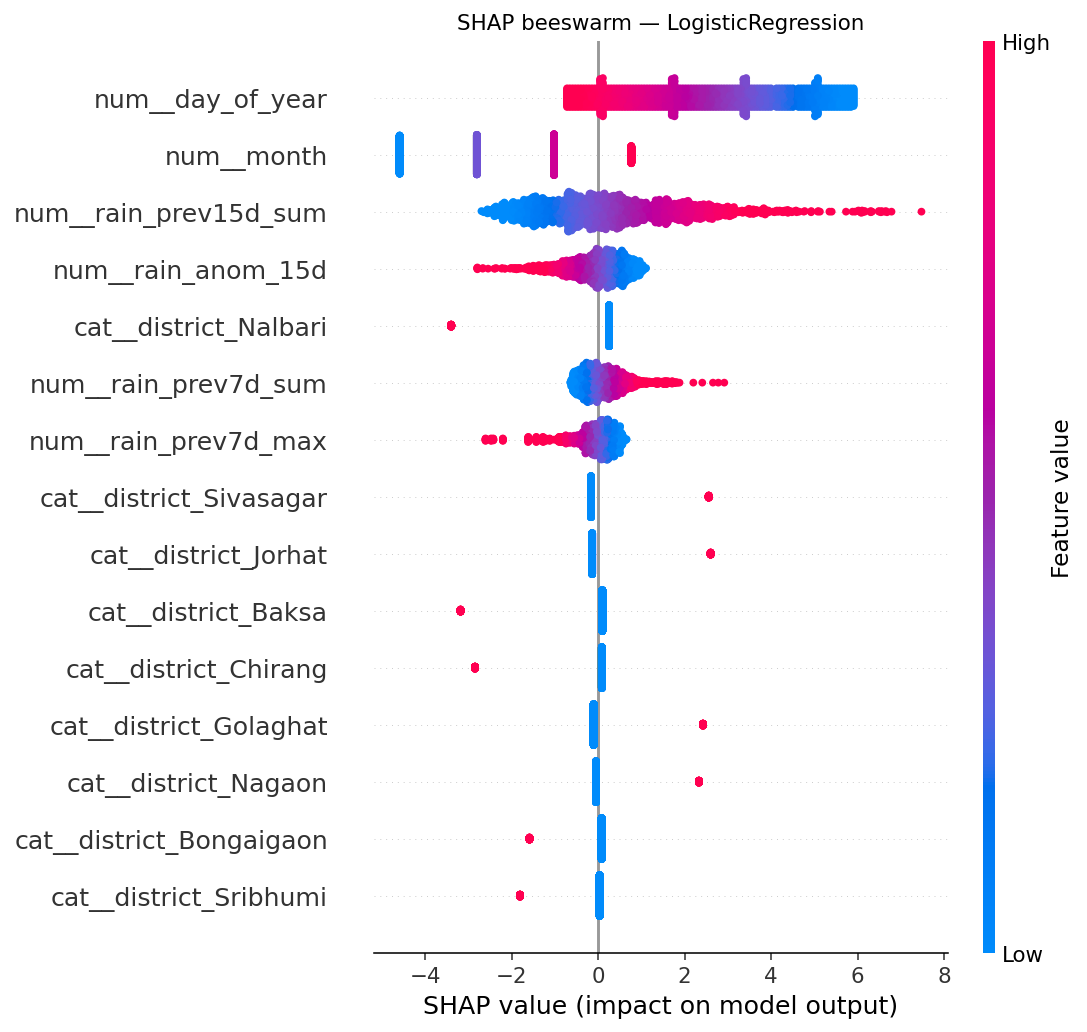

In [12]:
display(Image(filename=os.path.join(FIG, "shap_global_logreg_bar.png")))
display(Image(filename=os.path.join(FIG, "shap_global_logreg_beeswarm.png")))

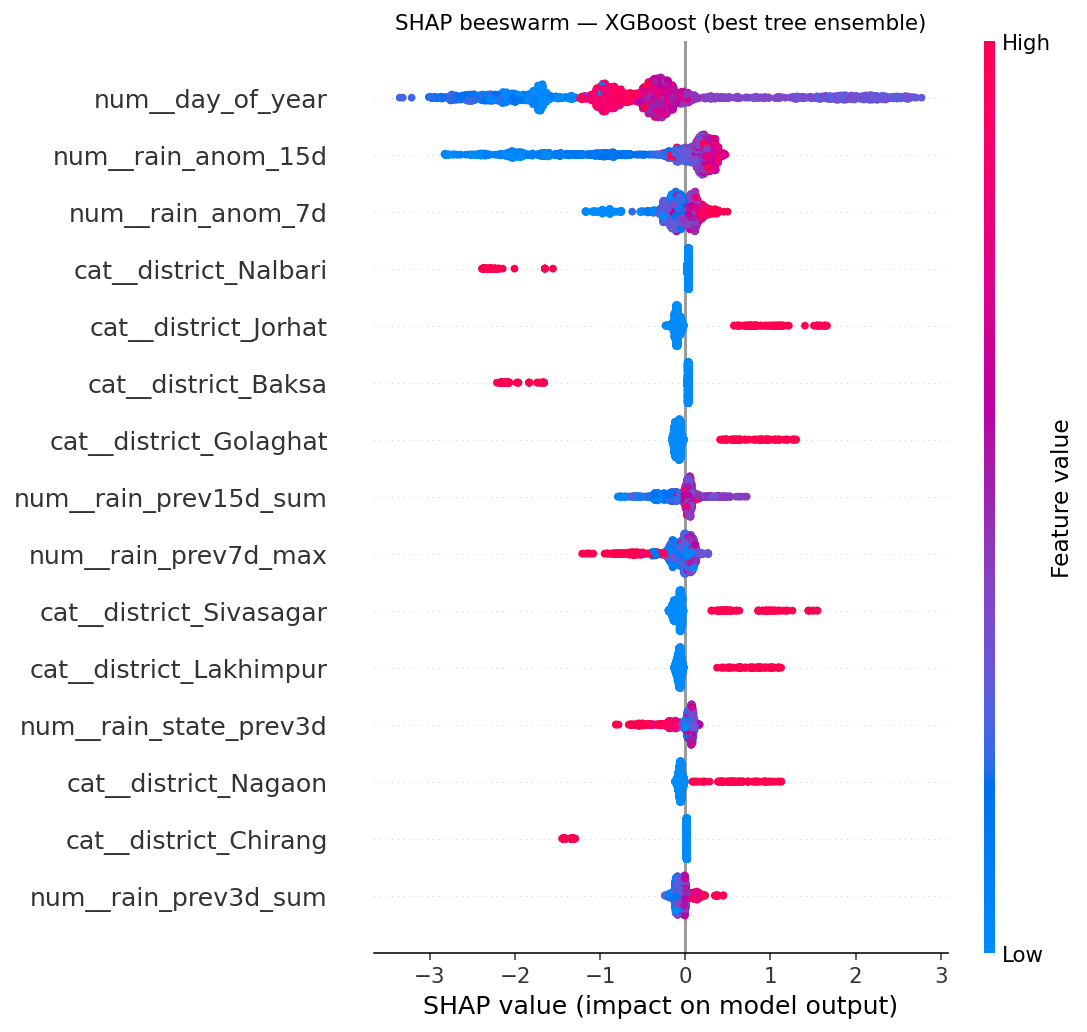

In [13]:
display(Image(filename=os.path.join(FIG, "shap_global_xgb_beeswarm.png")))

**Reading this in domain language:**

- **Accumulated rainfall over 15 days** is the strongest driver. That matches the physics:
  Assam's floods build as catchments and soils saturate over a fortnight, not from one storm.
- **Rainfall relative to the district's own norm** (`rain_anom_*`) carries real weight —
  confirming that *anomalous* rain matters more than absolute millimetres.
- **Seasonal position** (`month`, `day_of_year`) matters, which is expected but also a
  caution: part of what the model knows is simply *"it is peak monsoon"*.
- **District identity** still contributes, i.e. the model partly relies on which districts
  flood often. That is informative but not causal, and it is why the model transfers
  imperfectly across seasons.

### 5.2 Individual explanation — one specific prediction

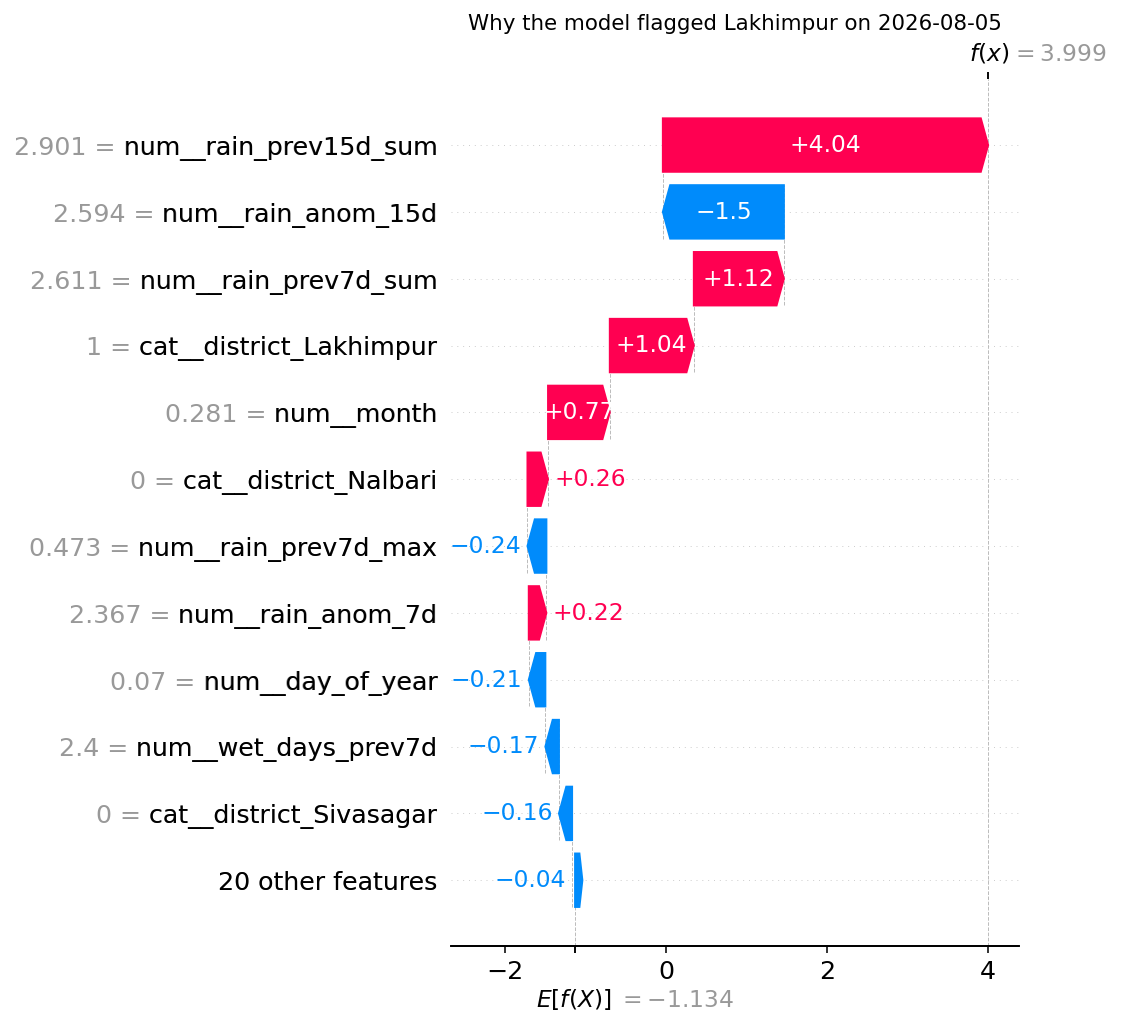

In [14]:
display(Image(filename=os.path.join(FIG, "shap_local_waterfall.png")))

In [15]:
print(open(os.path.join(MET, "explainability_notes.txt"), encoding="utf-8").read()[-1800:])

ar       2.646756
             num__month       2.509763
  num__rain_prev15d_sum       1.346982
     num__rain_anom_15d       0.507404
  cat__district_Nalbari       0.405219
   num__rain_prev7d_sum       0.372815
   num__rain_prev7d_max       0.339093
cat__district_Sivasagar       0.277412
   cat__district_Jorhat       0.253329
    cat__district_Baksa       0.245108
  cat__district_Chirang       0.219352
 cat__district_Golaghat       0.211787

--- global feature importance: XGBoost (top 12) ---
                feature  mean_abs_shap
       num__day_of_year       1.085481
     num__rain_anom_15d       0.541587
      num__rain_anom_7d       0.159265
  cat__district_Nalbari       0.142273
   cat__district_Jorhat       0.138269
    cat__district_Baksa       0.129659
 cat__district_Golaghat       0.125594
  num__rain_prev15d_sum       0.124672
   num__rain_prev7d_max       0.123624
cat__district_Sivasagar       0.120004
cat__district_Lakhimpur       0.105612
 num__rain_state_prev3d       0.

### 5.3 Contrast — a confident *no-flood* prediction

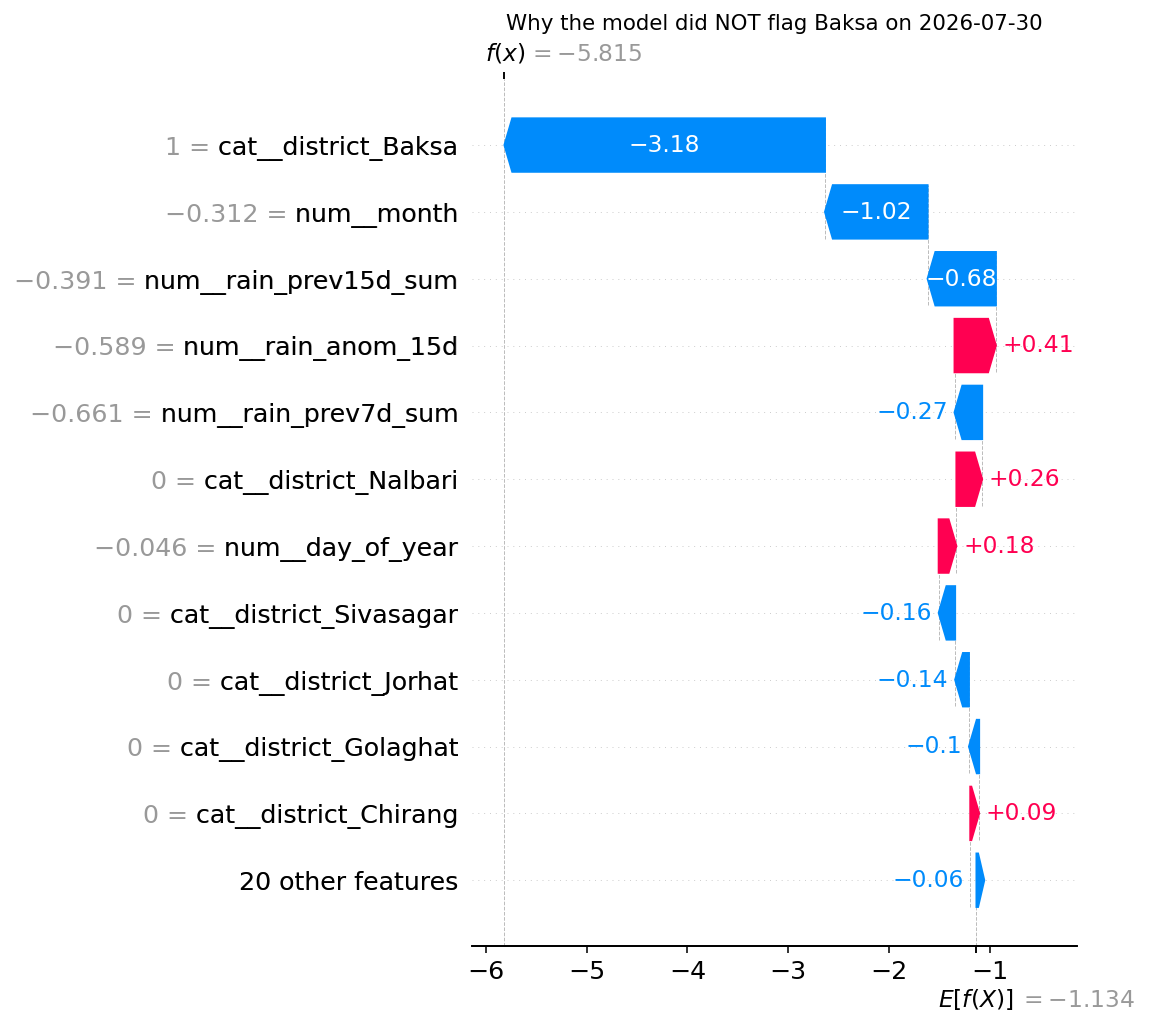

In [16]:
display(Image(filename=os.path.join(FIG, "shap_local_waterfall_negative.png")))

### 5.4 Ethics

Summarised here; the full statement is in **`ETHICS.md`**.

**False positive vs false negative.** A false positive wastes mobilisation and, repeated,
causes **alert fatigue** so the *next* warning is ignored. A false negative leaves
communities unprepared — risking life, livestock and crops. **These costs are not
symmetric**, which is why the threshold is a policy choice, not a statistical one.

**Bias — the most serious issue here is geographic.** Dhemaji, the *most* flood-affected
district, is excluded because CWC publishes almost no rainfall for it. 14 of 35 districts
are unmodellable. Exclusion tracks **monitoring infrastructure, not flood risk**, and
under-monitored districts are often the less-resourced ones. The model risks entrenching
existing measurement inequality.

**Privacy.** No personal data. Everything is district-level aggregate. The DRIMS reports do
contain affected-population counts, but these are aggregates and were excluded from the
features anyway on leakage grounds.

**Uncertainty.** Two seasons of labels; a partial test season; uncalibrated probabilities;
a single chronological split with no confidence interval.

**Human oversight.** Advisory only. Every prediction should be shown *with* its SHAP
explanation and *next to* the official CWC bulletin, and every prediction logged against
outcomes.

**Limits on deployment.** **This model should not be deployed operationally.** Recall is
well below a life-safety standard, it has never been independently validated, and it cannot
see river level, discharge or upstream rainfall — the variables that actually drive
Brahmaputra flooding.

---
## 6. Live demo — prediction on a synthetic record  *(Q5)*

The record below is **synthetic** — constructed by hand to be realistic for Lakhimpur in
peak monsoon. It is not an observation and is not presented as one.

In [17]:
!python ../src/predict_demo.py

LIVE DEMO - SYNTHETIC RECORD (not a real observation)
model      : Baseline: LogisticRegression
threshold  : 0.689   (tuned on the 2025 training season only)

district                : Lakhimpur
date (synthetic)        : day 200 of the year, month 7
rainfall, previous 3d   : 96 mm
rainfall, previous 7d   : 168 mm
rainfall, previous 15d  : 240 mm
vs district norm (7d)   : 2.60x
wet days in last 7      : 5
state-wide 3d rainfall  : 44 mm

------------------------------------------------------------------
PREDICTED FLOOD PROBABILITY : 0.918
DECISION (>= 0.689)          : FLOOD RISK FLAGGED
------------------------------------------------------------------

WHY (top local SHAP contributions):
   num__rain_prev15d_sum        +6.094  (raises the risk)
   num__rain_anom_15d           -4.440  (lowers the risk)
   num__rain_prev7d_sum         +2.534  (raises the risk)
   num__rain_prev7d_max         -2.092  (lowers the risk)
   cat__district_Lakhimpur      +1.044  (raises the risk)
   num__mont

Background dataset has 3611 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3611 when initializing the masker.


### Contrast: the same district in a quiet monsoon week

In [18]:
!python ../src/predict_demo.py --dry

LIVE DEMO - SYNTHETIC RECORD (not a real observation)
model      : Baseline: LogisticRegression
threshold  : 0.689   (tuned on the 2025 training season only)

district                : Lakhimpur
date (synthetic)        : day 200 of the year, month 7
rainfall, previous 3d   : 4 mm
rainfall, previous 7d   : 11 mm
rainfall, previous 15d  : 26 mm
vs district norm (7d)   : 0.17x
wet days in last 7      : 0
state-wide 3d rainfall  : 6 mm

------------------------------------------------------------------
PREDICTED FLOOD PROBABILITY : 0.187
DECISION (>= 0.689)          : no flag
------------------------------------------------------------------

WHY (top local SHAP contributions):
   num__rain_prev15d_sum        -1.764  (lowers the risk)
   cat__district_Lakhimpur      +1.044  (raises the risk)
   num__month                   -1.017  (lowers the risk)
   num__day_of_year             +0.877  (raises the risk)
   num__rain_anom_15d           +0.507  (raises the risk)
   num__rain_prev7d_sum    

Background dataset has 3611 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3611 when initializing the masker.


---
## 7. Conclusion

**What was built.** A complete, reproducible, leakage-safe ML pipeline that constructs an
Assam-specific flood dataset from two official government sources — 285 parsed ASDMA PDFs
and CWC rainfall records — and compares a baseline against bagging, boosting and
heterogeneous ensembles on a chronologically held-out flood season.

**What was learned.**
1. **Data work dominated.** The label source contained wrong report types, wrong dates and
   line-wrapped district names. Verification — not modelling — was where correctness was won.
2. **The ensemble did not beat the baseline**, and the analysis of *why* (monotonic signal,
   district-identity overfitting, one training season) is more valuable than a tuned win.
3. **SHAP caught a data leak** that the metrics hid — a feature that looked like a sensible
   control was partly encoding the outcome.

**What we would do with more data.** Add river level and discharge at the 26 official
danger-level gauges; add upstream rainfall from Arunachal, Bhutan and Meghalaya; extend
beyond two seasons; and press for rainfall monitoring in Dhemaji.

**Honest bottom line.** Publicly available rainfall alone carries a **weak but genuine**
flood signal (ROC-AUC ≈ 0.77 out-of-season). That is enough to demonstrate a sound ML
pipeline. It is **not** enough to protect anyone, and we say so.

---
### Reproducing this work
```bash
pip install -r requirements.txt
python src/parse_drims_reports.py     # 285 PDFs -> labels
python src/build_dataset.py           # join + audit -> processed dataset
python src/train_models.py            # all models + comparison
python src/explain_model.py           # SHAP global + local
python src/predict_demo.py            # live demo
```
Raw data can be re-downloaded with `src/download_raw_data.ps1` and
`src/download_drims_flood_reports.ps1`.